# INFS-768 Deliverable 1
Collin Brueggeman

## Problem Statement

Stroke is one of the leading causes of death and disability worldwide. Early prediction of stroke risk can lead to preventive healthcare interventions and reduce healthcare costs. Existing research shows that machine learning models can effectively identify high-risk individuals using health and lifestyle indicators.

The objective of this project is to use predictive analytics to develop a model that predicts the likelihood of stroke occurrence based on patient health attributes. This application of predictive analytics has practical significance for healthcare providers seeking to provide preventive care resources more effectively and can also help individuals make better health decisions.

## Data Dictionary

| Name | Type | Description |
| :---: | :---: | :--- |
| id | numeric | A unique identifier given to each individual patient. |
| gender | categorical | "Male", "Female", or "Other" based on the sex of a person or their opinion. |
| age | numeric | The specific age of the individual patient. |
| hypertension | categorical | Whether a patient has the hypertension condition, 1(yes) or 0(no). |
| heart_disease | categorical | Whether a patient has heart disease, 1(yes) or 0(no). |
| ever_married | categorical | Whether a patient has ever been married, "Yes" or "No". |
| work_type | categorical | What type of work the patient does. |
| Residence_type | categorical | What type of area is the patient's residence in ("Rural" or "Urban"). |
| avg_glucose_level | numeric | The average glucose level in the blood of the patient. |
| bmi | numeric | The BMI of the patient. |
| smoking_status | categorical | Status of a patient and their relationship to smoking, "formerly smoked", "never smoked", "smokes", or "Unknown". |
| stroke | categorical | If a patient had a stroke (1) or not (0). | 

Notes:

The dataset, Stroke Prediction Dataset, has been acquired from Kaggle. It is unclear from where the data within the dataset originated from. Some of the features have had encoding already done to them such as "heart_disease" while others such as "Residence_type" could benefit from encoding. Within the realm of health and lifestyle factors the variables appear to be of high quality. There is a chance for class imbalance within many of the variables and there will be a class imbalance for the stroke variable. Potential bias could include demographic imbalance (gender, Residence_type, age) or temporal bias if there are new clinical practices that are not found within the dataset.


## Data Imports

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn import preprocessing


In [32]:
#Import data into pandas dataframe
heart_data = pd.read_csv('healthcare-dataset-stroke-data.csv')

#View first ten rows of dataset
heart_data.head(10)

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
5,56669,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
6,53882,Male,74.0,1,1,Yes,Private,Rural,70.09,27.4,never smoked,1
7,10434,Female,69.0,0,0,No,Private,Urban,94.39,22.8,never smoked,1
8,27419,Female,59.0,0,0,Yes,Private,Rural,76.15,NaN,Unknown,1
9,60491,Female,78.0,0,0,Yes,Private,Urban,58.57,24.2,Unknown,1


In [33]:
#View features and data types
heart_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [34]:
#Provide statistical information on the dataset
heart_data.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [35]:
#Provide coorelation between numeric features
heart_data.corr(numeric_only=True).round(2)

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
id,1.00,0.00,0.00,-0.00,0.00,0.00,0.01
age,0.00,1.00,0.28,0.26,0.24,0.33,0.25
hypertension,0.00,0.28,1.00,0.11,0.17,0.17,0.13
heart_disease,-0.00,0.26,0.11,1.00,0.16,0.04,0.13
avg_glucose_level,0.00,0.24,0.17,0.16,1.00,0.18,0.13
bmi,0.00,0.33,0.17,0.04,0.18,1.00,0.04
stroke,0.01,0.25,0.13,0.13,0.13,0.04,1.00


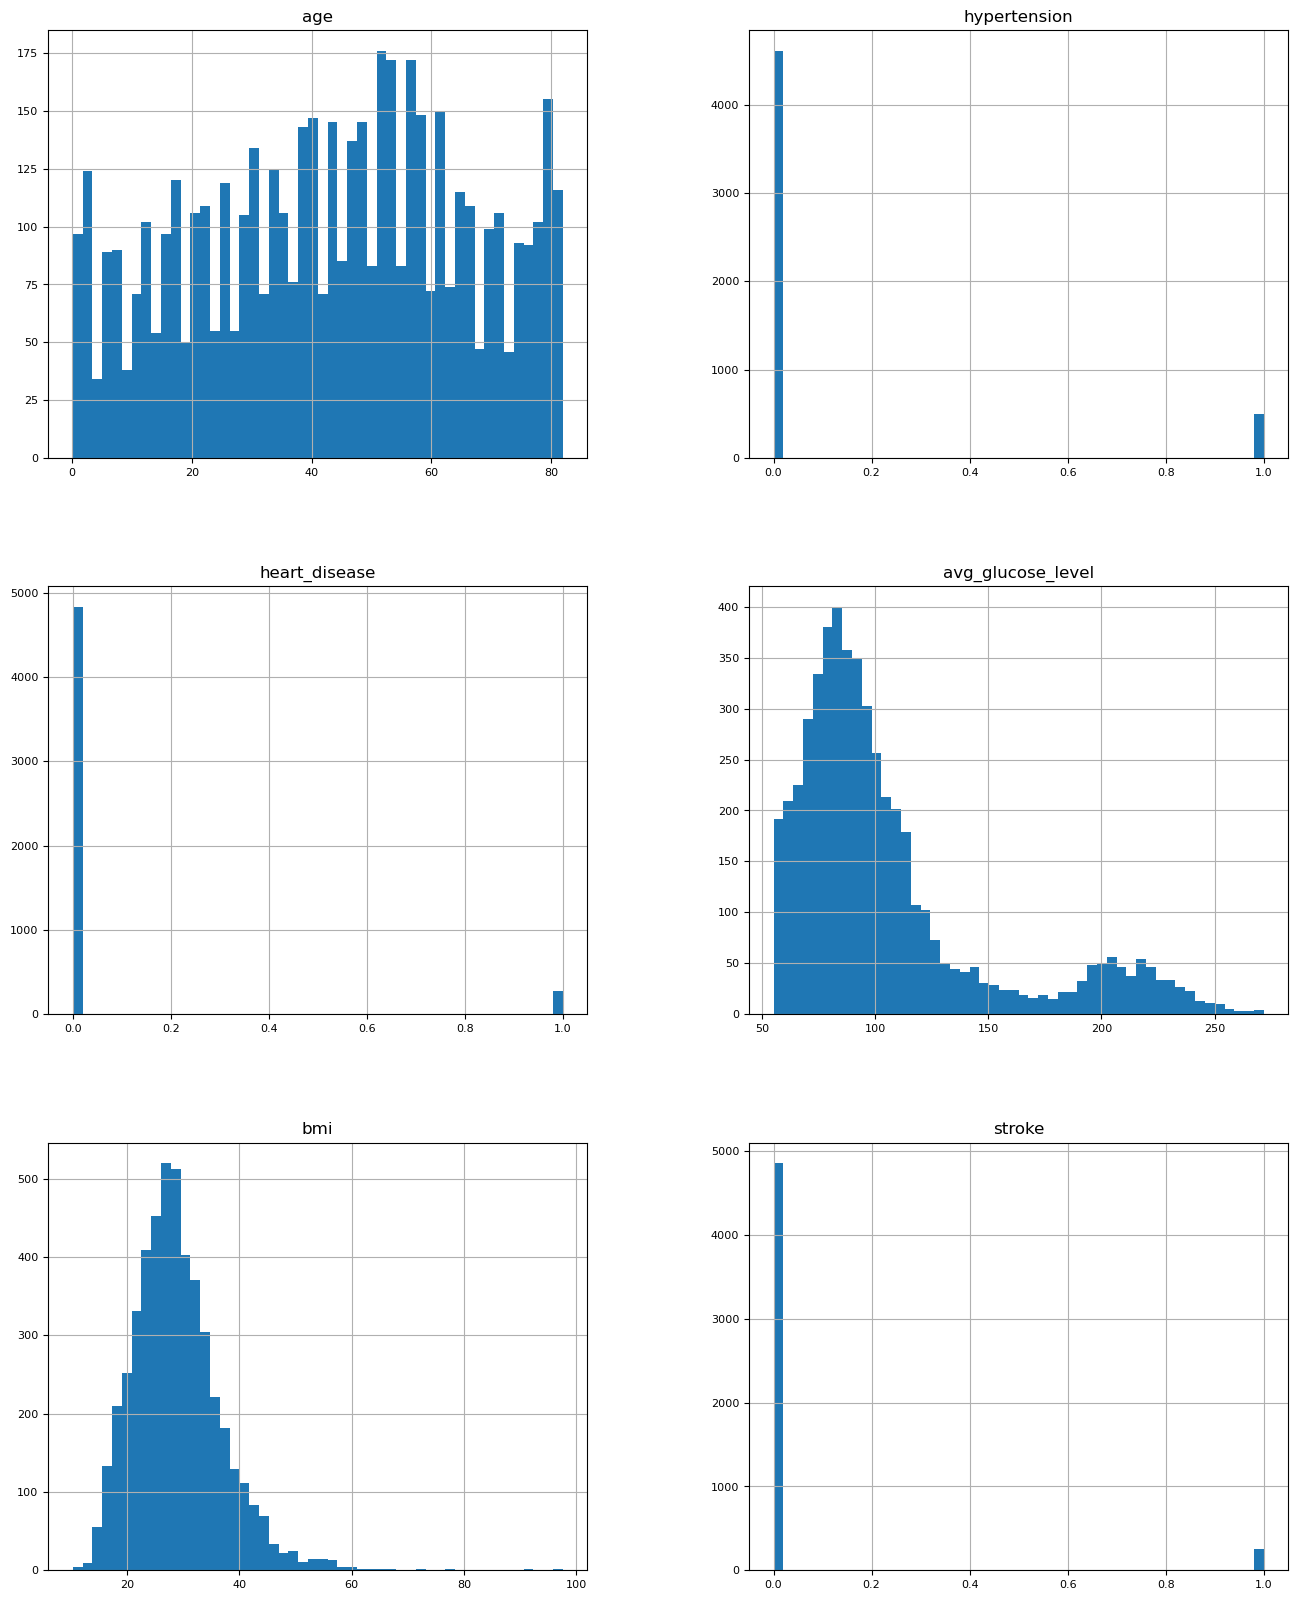

In [36]:
#Select Numeric features
heart_data_num = heart_data.select_dtypes(include = ['float64', 'int64'])

#Drop ID feature
heart_data_num.drop('id', axis=1, inplace=True)

#Create histograms of the remaining features (from EDA example notebook)
hist_num = heart_data_num.hist(figsize=(16, 20), bins=50, xlabelsize=8, ylabelsize=8)

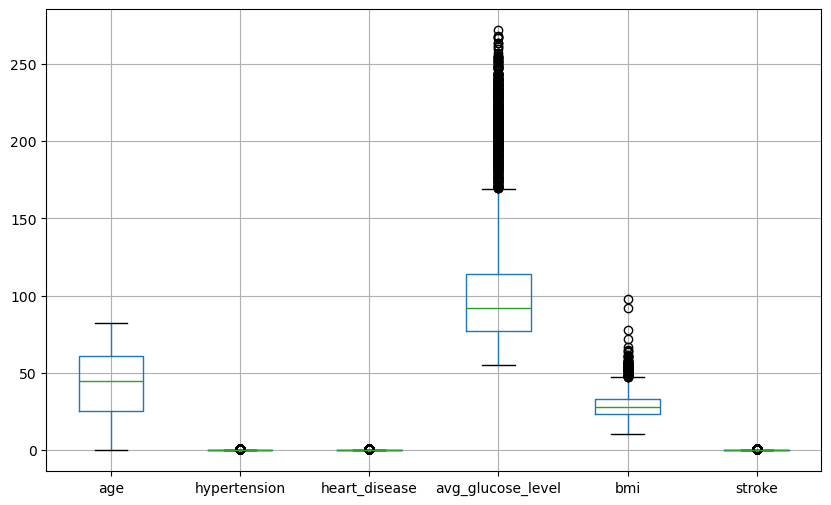

In [37]:
#Box plot for statistical visualization
plt.figure(figsize=(10,6))
heart_data_num.boxplot()
plt.show()

Data Structure and Initial Imppressions:

After taking my initial look into the dataset, I observed that there are 12 columns and 5110 rows. The variables within the dataset include both categorical features and numeric features.

The initial preview of the data has shown that most of the features are structured well, but there are some areas that will need to be addressed:
- The "bmi" feature contains missing values.
- The histogram plots highlight class imbalance over the "hypertension", "heart_disease", and "stroke" variables. Since the target variable within the dataset is imbalanced, techniques will be required to get the most out of the predictive model.
- Some categorical features such as "smoking_status" are stored as text strings and will need to be encoded.
- There are a few extreme values present within the "bmi" and "avg_glucose_level" that appear to potentially be extreme values and will need to be investigated further in the realm of medical conditions to see if they are possible values within the context of the dataset.

Overall, the dataset appears to be sufficiently large and diverse for the application of predictive analytics. There will need to be careful preproccessing done to the data to allow the models to perform at their highest level in predicting strokes in individuals.



## Data Cleaning

Missing values:
- Missing values such as the ones seen in the "bmi" feature could be imputed using median or regression-based imputation [5].
- For "Unknown" in "smoking_status", it could be encoded as a sperate category [6].

Duplicates:
- If duplicates are found they can be dropped from the dataset.

Outliers:
- If the number of outliers is low then they could be treated as missing data [5].
- Outliers could be transformed into more believable values on a case to case basis but that may lead to problems.

Irrelevant Fields:
- Irrelevant fields can be dropped (such as "id").

All of the above techniques can be found in our book [5] or the book by Kuhn & Johnson [6].

## Feature Selection

Possible Predictor Variables:
- gender, age, hypertension, heart_disease, ever_married, work_type, residence_type, avg_glucose_level, bmi, smoking_status

Target Variable:
- stroke (1 = yes, 0 = no)

The chosen possible predictor variables either align with known medical factors for stroke or capture an individual's lifestlye. The only variable at this time that I can say for certain won't be used is "id" because it is the equivalent of an index value and should not have any real predictive power. There is an opportunity for potential alternatives through feature engineering based on what is currently in the dataset if that will be in the scope of the project.

## Contextualization and Literature Link

Conventional risk scoring systems, such as the Framingham Stroke Risk Profile, provide a baseline approximation of an individuals’ risk, however do not account for nonlinear associations between variables or complex feature interactions. With the advancement of machine learning (ML) and predictive analytics, there has been research into algorithmic measures to improve accuracy and clinical decision making.


A recent systematic review published by Asadi et al. [1] details how an array of ML algorithms have been investigated for stroke prediction and noted ensemble and deep learning systems achieved significantly greater prediction performance on heterogeneous datasets. However, the authors also highlighted issues with class imbalance and generalizability. Research in these domains emphasizes the value of projects that test algorithms on real-world, patient-level data and incorporate methodologies to cleaning and feature selection of the data. A study in Scientific Reports [2] featured multiple ML algorithms to identify core risk factors (hypertension, glucose, BMI etc.), which reiterates the importance of careful selection of features in predicting health outcomes.


When using machine learning and predictive analytics to solve problems, interpretability is important. Dev et al. [3] showed that models could be trained using a smaller set of features (age, hypertension, heart disease, glucose, etc.) and still achieve very good predictive accuracy. This work shows the trade-off between model interpretability and clinical usefulness, which is an essential consideration to balance for predictive analytics projects so that aim to be deployed in real-world situations and provide effective insight. Finally, Ismail and Materwala [4] outline a framework for the end-to-end ML pipeline from data preparation steps to ML deployment frameworks in regards to stroke prediction projects. Their framework underscores the importance of reproducibility, performance assessments and deployment considerations. All of these will be important to keep in mind as I progress my project along.


Overall, these contributions demonstrate both the current promise of using predictive analytics for predicting strokes and some of the limitations that are currently being faced.. While advancements in ML technology have translated to improvement in prediction accuracy, issues such as class imbalance and interpretation of features as well as developing reproducible pipelines remain. This project aims to provide contribution to this area of work by implementing modern data cleaning and feature selection methodologies to a structured health care data set, creating predictive models, and evaluating the solution rigurously.


## Limitations and Future Considerations

Limitations:
- The dataset is highly imbalanced and predictive models could favor negative predictions if the imbalance is not addressed. This would undermine the value that is supposed to come from a stroke prediction model.
- Several predictors such as "smoking_status" come from self-reported data which could introduce measurement bias.
- The dataset includes a snippet of data from an individual at a certain time in their life and cannot give the full picture of the changes that happen in someone's life.

Future Considerations:
- Deeper analysis of demographic data will be required to ensure that there is fairness.
- Intepretable modeling will need to be a core feature of the project to maximize the value of the model as a tool for healthcare providers to give lifetlye suggestions to mitigate the risk of a stroke.
- Ethical considerations need to be taken into account as the data used is very personal and protected.

## References

[1]F. Asadi, M. Rahimi, A. H. Daeechini, and A. Paghe, “The most efficient machine learning algorithms in stroke prediction: A systematic review,” Health Science Reports, vol. 7, no. 10, Oct. 2024, doi: https://doi.org/10.1002/hsr2.70062.

[2]A. Hassan, S. Gulzar Ahmad, E. Ullah Munir, I. Ali Khan, and N. Ramzan, “Predictive modelling and identification of key risk factors for stroke using machine learning,” Scientific Reports, vol. 14, no. 1, p. 11498, May 2024, doi: https://doi.org/10.1038/s41598-024-61665-4.

[3]S. Dev, H. Wang, C. S. Nwosu, N. Jain, B. Veeravalli, and D. John, “A predictive analytics approach for stroke prediction using machine learning and neural networks,” arXiv.org, Mar. 01, 2022. https://arxiv.org/abs/2203.00497

[4]L. Ismail and Huned Materwala, “From Conception to Deployment: Intelligent Stroke Prediction Framework using Machine Learning and Performance Evaluation,” arXiv, pp. 1–7, Aug. 2022, doi: https://doi.org/10.1109/coins54846.2022.9854961.

[5]B. Peter, G. Shmueli, P. Gedeck, and N. R. Patel, DATA MINING FOR BUSINESS ANALYTICS : concepts, techniques and applications in python. S.L.: Wiley-Blackwell, 2020.

[6]M. Kuhn and K. Johnson, Feature Engineering and Selection. CRC Press, 2019.